# TCGA-OV / CMB-OV: CT-FM Study Figures

Population and results figures for the project write-up.

In [13]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
import os
os.makedirs('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures', exist_ok=True)

## Population Figures

### Pipeline funnel: patients retained at each stage

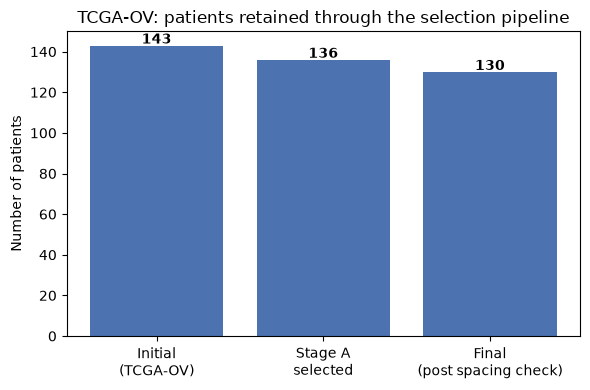

In [14]:
stages = ['Initial\n(TCGA-OV)', 'Stage A\nselected', 'Final\n(post spacing check)']
counts = [143, 136, 130]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(stages, counts, color='#4C72B0')
for i, c in enumerate(counts):
    ax.text(i, c + 1, str(c), ha='center', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_title('TCGA-OV: patients retained through the selection pipeline')
ax.set_ylim(0, 150)
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\tcga_ov_funnel.png')
plt.show()

### CLOVAR subtype distribution

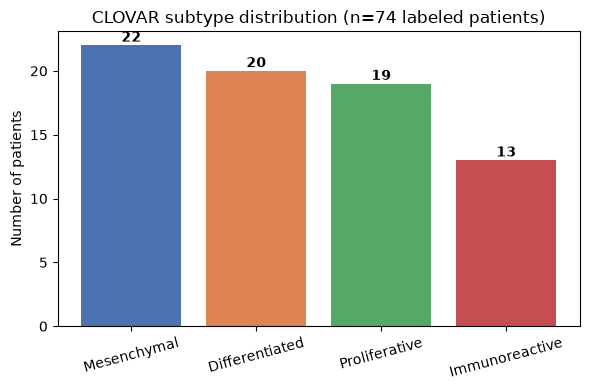

In [15]:
df = pd.read_csv('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\data\\series_lists\\tcga_ov_with_clovar_labels.csv')
counts = df['subtype'].value_counts(dropna=True)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
ax.bar(counts.index, counts.values, color=colors)
for i, c in enumerate(counts.values):
    ax.text(i, c + 0.3, str(c), ha='center', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_title(f'CLOVAR subtype distribution (n={counts.sum()} labeled patients)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\clovar_distribution.png')
plt.show()

### Slice thickness distribution (TCGA-OV, post Stage B)

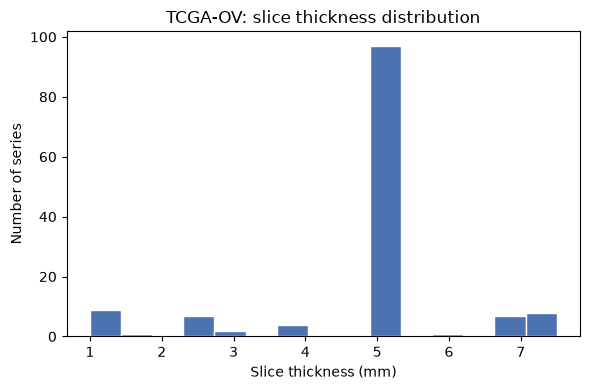

In [16]:
headers = pd.read_csv('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\data\\series_lists\\tcga_ov_stage_b_headers.csv')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(headers['SliceThickness'].dropna(), bins=15, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Slice thickness (mm)')
ax.set_ylabel('Number of series')
ax.set_title('TCGA-OV: slice thickness distribution')
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\slice_thickness_distribution.png')
plt.show()

## Results Figures

### Classifier comparison vs majority baseline

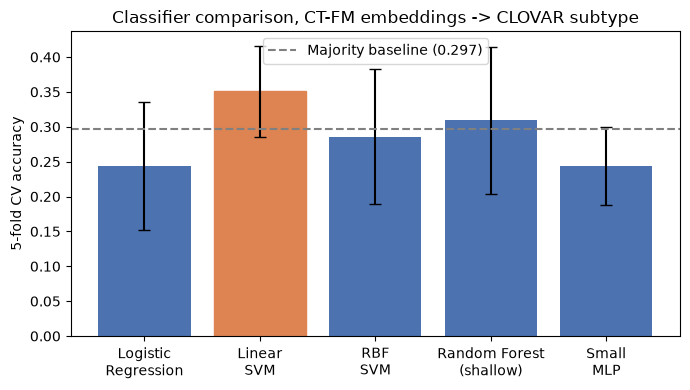

In [18]:
classifiers = ['Logistic\nRegression', 'Linear\nSVM', 'RBF\nSVM', 'Random Forest\n(shallow)', 'Small\nMLP']
means = [0.244, 0.351, 0.286, 0.309, 0.244]
stds = [0.092, 0.065, 0.097, 0.105, 0.056]
baseline = 0.297

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(classifiers, means, yerr=stds, capsize=4, color='#4C72B0')
bars[1].set_color('#DD8452')  # highlight Linear SVM, the standout result
ax.axhline(baseline, color='gray', linestyle='--', label=f'Majority baseline ({baseline:.3f})')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Classifier comparison, CT-FM embeddings -> CLOVAR subtype')
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\classifier_comparison.png')
plt.show()

### Permutation test: is Linear SVM's result above chance?

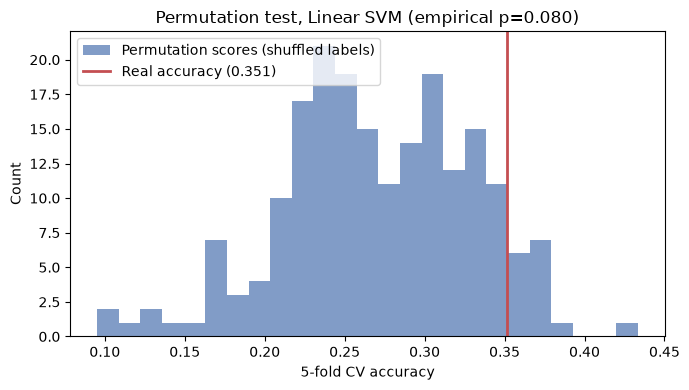

In [19]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

df = pd.read_csv('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\data\\series_lists\\tcga_ov_with_clovar_labels.csv').dropna(subset=['subtype'])
X = np.array([np.load(f"C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\embeddings\\tcga_ov\\{pid}.npy") for pid in df['PatientID']])
y = np.array(df['subtype'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components=5)), ('clf', SVC(kernel='linear', C=0.1))])

real_score = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy').mean()
rng = np.random.RandomState(42)
perm_scores = [cross_val_score(pipe, X, rng.permutation(y), cv=cv, scoring='accuracy').mean() for _ in range(200)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores, bins=25, color='#4C72B0', alpha=0.7, label='Permutation scores (shuffled labels)')
ax.axvline(real_score, color='#C44E52', linewidth=2, label=f'Real accuracy ({real_score:.3f})')
p_val = (np.array(perm_scores) >= real_score).sum() / len(perm_scores)
ax.set_xlabel('5-fold CV accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test, Linear SVM (empirical p={p_val:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\permutation_test.png')
plt.show()

### SHAP importance by CLOVAR subtype

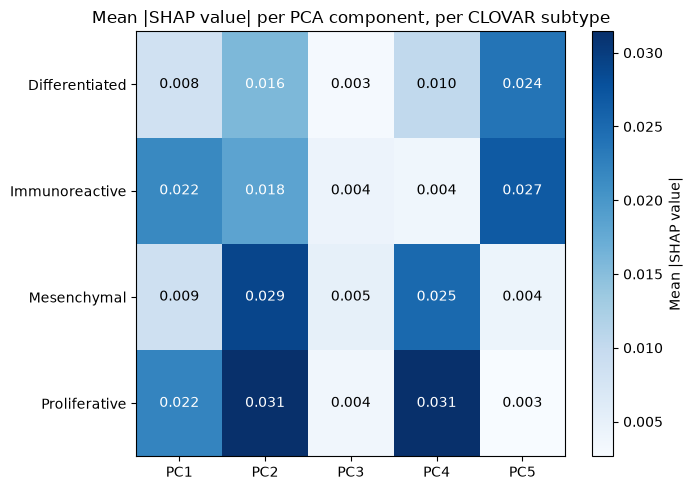

In [20]:
shap_values = np.load('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\embeddings\\tcga_ov_shap_values.npy')
classes = ['Differentiated', 'Immunoreactive', 'Mesenchymal', 'Proliferative']
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

importance = np.abs(shap_values).mean(axis=0).T  # shape: (classes, PCs)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(importance, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pcs)))
ax.set_xticklabels(pcs)
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes)
for i in range(len(classes)):
    for j in range(len(pcs)):
        ax.text(j, i, f'{importance[i, j]:.3f}', ha='center', va='center',
                color='white' if importance[i, j] > importance.max()/2 else 'black')
ax.set_title('Mean |SHAP value| per PCA component, per CLOVAR subtype')
plt.colorbar(im, label='Mean |SHAP value|')
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\shap_heatmap.png')
plt.show()

### TCGA-OV vs CMB-OV embedding space (PCA)

In [1]:
tcga_pca = pd.read_csv('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\embeddings\\pca_comparison.csv')
cmb_pca = pd.read_csv('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\embeddings\\pca_comparison_cmb.csv')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(tcga_pca['PC1'], tcga_pca['PC2'], alpha=0.5, s=40, color='#4C72B0', label=f'TCGA-OV (n={len(tcga_pca)}, pretraining-exposed)')
ax.scatter(cmb_pca['PC1'], cmb_pca['PC2'], alpha=0.9, s=100, color='#C44E52', marker='^', label=f'CMB-OV (n={len(cmb_pca)}, held-out)', edgecolor='black')

tcga_centroid = tcga_pca[['PC1', 'PC2']].mean()
cmb_centroid = cmb_pca[['PC1', 'PC2']].mean()
ax.scatter(*tcga_centroid, color='#4C72B0', marker='X', s=300, edgecolor='black', linewidth=2, zorder=5)
ax.scatter(*cmb_centroid, color='#C44E52', marker='X', s=300, edgecolor='black', linewidth=2, zorder=5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('CT-FM embedding space: TCGA-OV (pretraining-exposed) vs CMB-OV (held-out)\n(X markers = dataset centroids)')
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\s233183\\OneDrive - Danmarks Tekniske Universitet\\Desktop\\personal projects\\TCIA vs CT-FM Merlin\\outputs\\figures\\tcga_vs_cmb_pca.png')
plt.show()

NameError: name 'pd' is not defined